In [1]:
# ============================================================
# PHASE 3.1 — MULTIMODAL INTEGRATION MODELLING
# Colab-stable version with lightweight GridSearchCV + checkpoint
# ============================================================

import json
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import joblib

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    ParameterGrid
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    make_scorer,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

In [2]:
# ============================================================
# PATHS
# ============================================================
import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE3_DATA_DIR = PHASE3_DIR / "shared_dataset"
PHASE3_FEATURE_DIR = PHASE3_DIR / "features"

PHASE3_1_DIR = PHASE3_DIR / "phase3_1_modelling_light"
RESULT_DIR = PHASE3_1_DIR / "results"
MODEL_DIR = PHASE3_1_DIR / "models"
FIGURE_DIR = PHASE3_1_DIR / "figures"
REPORT_DIR = PHASE3_1_DIR / "reports"

CHECKPOINT_MODEL_DIR = MODEL_DIR / "gridsearch_checkpoints"

for folder in [
    PHASE3_1_DIR,
    RESULT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    CHECKPOINT_MODEL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 3.1 output:", PHASE3_1_DIR)

Mounted at /content/drive
Phase 3.1 output: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light


In [3]:
# ============================================================
# LOAD SHARED MULTIMODAL DATASET
# ============================================================

# Metadata
train_meta = pd.read_csv(PHASE3_DATA_DIR / "train_multimodal_metadata_v1.csv")
val_meta = pd.read_csv(PHASE3_DATA_DIR / "val_multimodal_metadata_v1.csv")
test_meta = pd.read_csv(PHASE3_DATA_DIR / "test_multimodal_metadata_v1.csv")

# Labels
y_train = np.load(PHASE3_DATA_DIR / "y_train_multimodal_v1.npy")
y_val = np.load(PHASE3_DATA_DIR / "y_val_multimodal_v1.npy")
y_test = np.load(PHASE3_DATA_DIR / "y_test_multimodal_v1.npy")

# Protein features
X_train_protein = np.load(PHASE3_FEATURE_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein = np.load(PHASE3_FEATURE_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein = np.load(PHASE3_FEATURE_DIR / "X_test_protein_protbert_sw_v1.npy")

# Genomic features
X_train_genomic = pd.read_csv(PHASE3_FEATURE_DIR / "X_train_genomic_k3k4basic_v1.csv")
X_val_genomic = pd.read_csv(PHASE3_FEATURE_DIR / "X_val_genomic_k3k4basic_v1.csv")
X_test_genomic = pd.read_csv(PHASE3_FEATURE_DIR / "X_test_genomic_k3k4basic_v1.csv")

# Combined features
X_train_combined = np.load(PHASE3_FEATURE_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_combined = np.load(PHASE3_FEATURE_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_combined = np.load(PHASE3_FEATURE_DIR / "X_test_combined_protein_genomic_v1.npy")

print("Train meta:", train_meta.shape)
print("Val meta:", val_meta.shape)
print("Test meta:", test_meta.shape)

print("\nProtein:", X_train_protein.shape, X_val_protein.shape, X_test_protein.shape)
print("Genomic:", X_train_genomic.shape, X_val_genomic.shape, X_test_genomic.shape)
print("Combined:", X_train_combined.shape, X_val_combined.shape, X_test_combined.shape)

print("\nLabel distribution:")
print("Train:")
print(pd.Series(y_train).value_counts().sort_index())
print("Validation:")
print(pd.Series(y_val).value_counts().sort_index())
print("Test:")
print(pd.Series(y_test).value_counts().sort_index())

assert X_train_protein.shape[0] == len(y_train)
assert X_train_genomic.shape[0] == len(y_train)
assert X_train_combined.shape[0] == len(y_train)

assert X_val_protein.shape[0] == len(y_val)
assert X_val_genomic.shape[0] == len(y_val)
assert X_val_combined.shape[0] == len(y_val)

assert X_test_protein.shape[0] == len(y_test)
assert X_test_genomic.shape[0] == len(y_test)
assert X_test_combined.shape[0] == len(y_test)

print("\n✅ Shared multimodal dataset loaded successfully.")

Train meta: (1264, 12)
Val meta: (271, 12)
Test meta: (271, 12)

Protein: (1264, 1024) (271, 1024) (271, 1024)
Genomic: (1264, 356) (271, 356) (271, 356)
Combined: (1264, 1380) (271, 1380) (271, 1380)

Label distribution:
Train:
0    632
1    632
Name: count, dtype: int64
Validation:
0    135
1    136
Name: count, dtype: int64
Test:
0    136
1    135
Name: count, dtype: int64

✅ Shared multimodal dataset loaded successfully.


In [4]:
# ============================================================
# FEATURE SET DEFINITIONS
# ============================================================

feature_sets = {
    "Protein-only ProtBERT-SW": {
        "X_train": X_train_protein,
        "X_val": X_val_protein,
        "X_test": X_test_protein,
        "n_features": X_train_protein.shape[1],
        "modality": "protein"
    },
    "Genomic-only K3K4Basic": {
        "X_train": X_train_genomic,
        "X_val": X_val_genomic,
        "X_test": X_test_genomic,
        "n_features": X_train_genomic.shape[1],
        "modality": "genomic"
    },
    "Combined Protein+Genomic": {
        "X_train": X_train_combined,
        "X_val": X_val_combined,
        "X_test": X_test_combined,
        "n_features": X_train_combined.shape[1],
        "modality": "multimodal"
    }
}

feature_set_summary_df = pd.DataFrame([
    {
        "feature_set": name,
        "modality": info["modality"],
        "n_train": info["X_train"].shape[0],
        "n_val": info["X_val"].shape[0],
        "n_test": info["X_test"].shape[0],
        "n_features": info["n_features"]
    }
    for name, info in feature_sets.items()
])

display(feature_set_summary_df)

feature_set_summary_df.to_csv(
    RESULT_DIR / "phase3_1_feature_set_summary.csv",
    index=False
)

,feature_set,modality,n_train,n_val,n_test,n_features
0,Protein-only ProtBERT-SW,protein,1264,271,271,1024
1,Genomic-only K3K4Basic,genomic,1264,271,271,356
2,Combined Protein+Genomic,multimodal,1264,271,271,1380


In [5]:
# ============================================================
# COMPUTE CONTROLS
# ============================================================

# 5-fold is still okay with lightweight grid.
# If Colab is still unstable, change n_splits to 3.
N_SPLITS = 5

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "mcc": make_scorer(matthews_corrcoef)
}

# Colab stability: avoid all CPU cores.
GRID_N_JOBS = 1
GRID_VERBOSE = 1

# LightGBM control.
# Recommendation: run LightGBM only for genomic first.
RUN_LIGHTGBM_FOR_PROTEIN = False
RUN_LIGHTGBM_FOR_GENOMIC = True
RUN_LIGHTGBM_FOR_COMBINED = False

print("CV folds:", N_SPLITS)
print("GRID_N_JOBS:", GRID_N_JOBS)
print("RUN_LIGHTGBM_FOR_PROTEIN:", RUN_LIGHTGBM_FOR_PROTEIN)
print("RUN_LIGHTGBM_FOR_GENOMIC:", RUN_LIGHTGBM_FOR_GENOMIC)
print("RUN_LIGHTGBM_FOR_COMBINED:", RUN_LIGHTGBM_FOR_COMBINED)

CV folds: 5
GRID_N_JOBS: 1
RUN_LIGHTGBM_FOR_PROTEIN: False
RUN_LIGHTGBM_FOR_GENOMIC: True
RUN_LIGHTGBM_FOR_COMBINED: False


In [6]:
# ============================================================
# METRIC HELPERS
# ============================================================

def get_positive_class_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_binary_classifier(model, X, y, model_name, dataset_name, feature_set_name, modality):
    y_pred = model.predict(X)
    y_score = get_positive_class_score(model, X)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "feature_set": feature_set_name,
        "modality": modality,
        "model": model_name,
        "dataset": dataset_name,

        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y, y_pred, zero_division=0),

        "roc_auc": roc_auc_score(y, y_score),
        "pr_auc": average_precision_score(y, y_score),
        "mcc": matthews_corrcoef(y, y_pred),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def evaluate_with_threshold(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    recall_value = recall_score(y_true, y_pred, zero_division=0)
    balanced_accuracy = (recall_value + specificity) / 2
    youden_j = recall_value + specificity - 1

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_value,
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "youden_j": youden_j,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def safe_name(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
        .replace("/", "_")
    )

In [7]:
# ============================================================
# MODEL BUILDERS
# ============================================================

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False


def build_base_models():
    models = {
        "Logistic Regression": Pipeline([
            ("variance", VarianceThreshold(threshold=0.0)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                random_state=42
            ))
        ]),

        "SVM RBF": Pipeline([
            ("variance", VarianceThreshold(threshold=0.0)),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            ))
        ]),

        "Random Forest": Pipeline([
            ("variance", VarianceThreshold(threshold=0.0)),
            ("model", RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=1
            ))
        ])
    }

    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = Pipeline([
            ("variance", VarianceThreshold(threshold=0.0)),
            ("model", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                num_leaves=15,
                random_state=42,
                n_jobs=1,
                verbose=-1
            ))
        ])
    else:
        models["Hist Gradient Boosting"] = Pipeline([
            ("variance", VarianceThreshold(threshold=0.0)),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                random_state=42
            ))
        ])

    return models


print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("Models:", list(build_base_models().keys()))

LightGBM available: True
Models: ['Logistic Regression', 'SVM RBF', 'Random Forest', 'LightGBM']


In [8]:
# ============================================================
# LIGHTWEIGHT PARAMETER GRIDS
# ============================================================

def get_light_param_grids():
    grids = {
        "Logistic Regression": {
            "model__C": [0.0003, 0.001, 0.003, 0.01, 0.03],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"]
        },

        "SVM RBF": {
            "model__C": [0.1, 1, 3],
            "model__gamma": ["scale", 0.001, 0.01]
        },

        "Random Forest": {
            "model__n_estimators": [300],
            "model__max_depth": [8, 10, None],
            "model__min_samples_leaf": [5, 10],
            "model__max_features": ["sqrt"],
            "model__bootstrap": [True]
        }
    }

    if LIGHTGBM_AVAILABLE:
        grids["LightGBM"] = {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05],
            "model__num_leaves": [7, 15],
            "model__max_depth": [3],
            "model__min_child_samples": [30, 50],
            "model__subsample": [0.8],
            "model__colsample_bytree": [0.8],
            "model__reg_alpha": [0.1],
            "model__reg_lambda": [1, 5]
        }
    else:
        grids["Hist Gradient Boosting"] = {
            "model__learning_rate": [0.03, 0.05],
            "model__max_iter": [100, 200],
            "model__max_leaf_nodes": [15, 31],
            "model__min_samples_leaf": [30, 50]
        }

    return grids


param_grids = get_light_param_grids()

for model_name, grid in param_grids.items():
    n_candidates = len(list(ParameterGrid(grid)))
    print(model_name, "| candidates:", n_candidates, "| total fits:", n_candidates * N_SPLITS)

Logistic Regression | candidates: 5 | total fits: 25
SVM RBF | candidates: 9 | total fits: 45
Random Forest | candidates: 6 | total fits: 30
LightGBM | candidates: 32 | total fits: 160


In [9]:
# ============================================================
# OPTIONAL BASELINE 5-FOLD CV ACROSS MODALITIES
# You can skip this if Colab is unstable.
# ============================================================

RUN_BASELINE_CV = True

if RUN_BASELINE_CV:
    baseline_cv_records = []

    for feature_set_name, fs in feature_sets.items():
        print("=" * 100)
        print("Feature set:", feature_set_name)

        models = build_base_models()

        for model_name, pipeline in models.items():

            if model_name == "LightGBM":
                if fs["modality"] == "protein" and not RUN_LIGHTGBM_FOR_PROTEIN:
                    print("Skipped LightGBM for protein baseline CV.")
                    continue
                if fs["modality"] == "genomic" and not RUN_LIGHTGBM_FOR_GENOMIC:
                    print("Skipped LightGBM for genomic baseline CV.")
                    continue
                if fs["modality"] == "multimodal" and not RUN_LIGHTGBM_FOR_COMBINED:
                    print("Skipped LightGBM for combined baseline CV.")
                    continue

            print("CV:", model_name)

            cv_output = cross_validate(
                estimator=pipeline,
                X=fs["X_train"],
                y=y_train,
                cv=cv,
                scoring=scoring,
                n_jobs=1,
                return_train_score=True
            )

            row = {
                "feature_set": feature_set_name,
                "modality": fs["modality"],
                "n_features": fs["n_features"],
                "model": model_name,

                "train_roc_auc_mean": cv_output["train_roc_auc"].mean(),
                "train_roc_auc_std": cv_output["train_roc_auc"].std(),

                "cv_roc_auc_mean": cv_output["test_roc_auc"].mean(),
                "cv_roc_auc_std": cv_output["test_roc_auc"].std(),

                "cv_f1_mean": cv_output["test_f1"].mean(),
                "cv_f1_std": cv_output["test_f1"].std(),

                "cv_pr_auc_mean": cv_output["test_pr_auc"].mean(),
                "cv_pr_auc_std": cv_output["test_pr_auc"].std(),

                "cv_mcc_mean": cv_output["test_mcc"].mean(),
                "cv_mcc_std": cv_output["test_mcc"].std(),

                "overfit_gap_train_minus_cv": (
                    cv_output["train_roc_auc"].mean() - cv_output["test_roc_auc"].mean()
                )
            }

            baseline_cv_records.append(row)

    baseline_cv_df = pd.DataFrame(baseline_cv_records).sort_values(
        by=["cv_roc_auc_mean", "cv_mcc_mean"],
        ascending=False
    )

    display(baseline_cv_df)

    baseline_cv_df.to_csv(
        RESULT_DIR / "phase3_1_baseline_cv_all_modalities_light.csv",
        index=False
    )
else:
    print("Skipped baseline CV.")

Feature set: Protein-only ProtBERT-SW
CV: Logistic Regression
CV: SVM RBF
CV: Random Forest
Skipped LightGBM for protein baseline CV.
Feature set: Genomic-only K3K4Basic
CV: Logistic Regression
CV: SVM RBF
CV: Random Forest
CV: LightGBM
Feature set: Combined Protein+Genomic
CV: Logistic Regression
CV: SVM RBF
CV: Random Forest
Skipped LightGBM for combined baseline CV.


,feature_set,modality,n_features,model,train_roc_auc_mean,train_roc_auc_std,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_mean,cv_f1_std,cv_pr_auc_mean,cv_pr_auc_std,cv_mcc_mean,cv_mcc_std,overfit_gap_train_minus_cv
8,Combined Protein+Genomic,multimodal,1380,SVM RBF,0.969070,1.478639e-03,0.713564,0.020163,0.659111,0.014507,0.702228,0.035576,0.312473,0.025457,0.255506
9,Combined Protein+Genomic,multimodal,1380,Random Forest,1.000000,0.000000e+00,0.709308,0.034386,0.656996,0.017273,0.696442,0.040399,0.294549,0.045405,0.290692
1,Protein-only ProtBERT-SW,protein,1024,SVM RBF,0.937969,3.020541e-03,0.707658,0.026230,0.651386,0.024678,0.677761,0.037794,0.284675,0.044973,0.230311
2,Protein-only ProtBERT-SW,protein,1024,Random Forest,1.000000,0.000000e+00,0.695032,0.036178,0.631617,0.026709,0.677463,0.042900,0.255556,0.054554,0.304968
7,Combined Protein+Genomic,multimodal,1380,Logistic Regression,1.000000,0.000000e+00,0.657966,0.021843,0.617435,0.024777,0.638012,0.032485,0.233684,0.023654,0.342034
4,Genomic-only K3K4Basic,genomic,356,SVM RBF,0.951274,2.691712e-03,0.635025,0.019048,0.582101,0.021197,0.630407,0.018205,0.214226,0.045502,0.316249
0,Protein-only ProtBERT-SW,protein,1024,Logistic Regression,0.999999,1.565374e-06,0.632893,0.017487,0.601964,0.026746,0.611608,0.026288,0.215286,0.020674,0.367106
5,Genomic-only K3K4Basic,genomic,356,Random Forest,1.000000,7.021667e-17,0.626265,0.022425,0.582933,0.029021,0.633671,0.022039,0.197412,0.060149,0.373735
6,Genomic-only K3K4Basic,genomic,356,LightGBM,1.000000,0.000000e+00,0.600264,0.026269,0.574073,0.027992,0.606432,0.031529,0.166485,0.037635,0.399736
3,Genomic-only K3K4Basic,genomic,356,Logistic Regression,0.816043,4.110498e-03,0.583664,0.019307,0.562777,0.018068,0.572255,0.029021,0.122197,0.048775,0.232379


In [10]:
# ============================================================
# SAFE GRIDSEARCHCV WITH CHECKPOINT / RESUME
# ============================================================

grid_results_path = RESULT_DIR / "phase3_1_gridsearch_results_all_modalities_checkpoint.csv"

# Load previous checkpoint if exists
if grid_results_path.exists():
    grid_results_df_existing = pd.read_csv(grid_results_path)
    completed_jobs = set(
        zip(
            grid_results_df_existing["feature_set"],
            grid_results_df_existing["model"]
        )
    )
    grid_results = grid_results_df_existing.to_dict("records")
    print("Loaded existing checkpoint:", grid_results_path)
    print("Completed jobs:", len(completed_jobs))
else:
    completed_jobs = set()
    grid_results = []
    print("No checkpoint found. Starting fresh.")

best_estimators = {}

for feature_set_name in feature_sets.keys():
    best_estimators[feature_set_name] = {}

# Load existing estimator checkpoints if available
for feature_set_name in feature_sets.keys():
    safe_feature_set = safe_name(feature_set_name)

    for model_file in CHECKPOINT_MODEL_DIR.glob(f"{safe_feature_set}_*.pkl"):
        loaded_model = joblib.load(model_file)

        model_key = model_file.stem.replace(f"{safe_feature_set}_", "")

        # Map safe model names back to display names
        reverse_model_map = {
            "logistic_regression": "Logistic Regression",
            "svm_rbf": "SVM RBF",
            "random_forest": "Random Forest",
            "lightgbm": "LightGBM",
            "hist_gradient_boosting": "Hist Gradient Boosting"
        }

        model_display_name = reverse_model_map.get(model_key, model_key)

        best_estimators[feature_set_name][model_display_name] = loaded_model

print("Existing estimator checkpoints loaded.")

No checkpoint found. Starting fresh.
Existing estimator checkpoints loaded.


In [11]:
# ============================================================
# RUN LIGHTWEIGHT GRIDSEARCHCV
# ============================================================

param_grids = get_light_param_grids()

for feature_set_name, fs in feature_sets.items():
    print("=" * 100)
    print("Feature set:", feature_set_name)

    models = build_base_models()

    for model_name, pipeline in models.items():

        # Skip LightGBM selectively
        if model_name == "LightGBM":
            if fs["modality"] == "protein" and not RUN_LIGHTGBM_FOR_PROTEIN:
                print("Skipped LightGBM for protein.")
                continue

            if fs["modality"] == "genomic" and not RUN_LIGHTGBM_FOR_GENOMIC:
                print("Skipped LightGBM for genomic.")
                continue

            if fs["modality"] == "multimodal" and not RUN_LIGHTGBM_FOR_COMBINED:
                print("Skipped LightGBM for combined.")
                continue

        job_key = (feature_set_name, model_name)

        if job_key in completed_jobs:
            print("-" * 100)
            print("Already completed, skipping:", feature_set_name, "|", model_name)
            continue

        print("-" * 100)
        print("GridSearchCV:", feature_set_name, "|", model_name)

        n_candidates = len(list(ParameterGrid(param_grids[model_name])))
        print("Candidates:", n_candidates)
        print("Total fits:", n_candidates * N_SPLITS)

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring="roc_auc",
            cv=cv,
            n_jobs=GRID_N_JOBS,
            refit=True,
            return_train_score=True,
            verbose=GRID_VERBOSE
        )

        grid.fit(fs["X_train"], y_train)

        best_idx = grid.best_index_

        row = {
            "feature_set": feature_set_name,
            "modality": fs["modality"],
            "n_features": fs["n_features"],
            "model": model_name,
            "best_cv_roc_auc": grid.best_score_,
            "best_train_roc_auc": grid.cv_results_["mean_train_score"][best_idx],
            "overfit_gap_train_minus_cv": (
                grid.cv_results_["mean_train_score"][best_idx] - grid.best_score_
            ),
            "best_params": str(grid.best_params_)
        }

        grid_results.append(row)

        # Save model checkpoint immediately
        safe_feature_set = safe_name(feature_set_name)
        safe_model_name = safe_name(model_name)

        model_checkpoint_path = CHECKPOINT_MODEL_DIR / f"{safe_feature_set}_{safe_model_name}.pkl"
        joblib.dump(grid.best_estimator_, model_checkpoint_path)

        best_estimators[feature_set_name][model_name] = grid.best_estimator_

        # Save CSV checkpoint immediately
        grid_results_df_checkpoint = pd.DataFrame(grid_results).drop_duplicates(
            subset=["feature_set", "model"],
            keep="last"
        ).sort_values(
            by=["best_cv_roc_auc", "overfit_gap_train_minus_cv"],
            ascending=[False, True]
        )

        grid_results_df_checkpoint.to_csv(grid_results_path, index=False)

        completed_jobs.add(job_key)

        print("Best CV ROC-AUC:", grid.best_score_)
        print("Best train ROC-AUC:", grid.cv_results_["mean_train_score"][best_idx])
        print("Gap:", row["overfit_gap_train_minus_cv"])
        print("Best params:", grid.best_params_)
        print("Saved model checkpoint:", model_checkpoint_path)
        print("Saved result checkpoint:", grid_results_path)

grid_results_df = pd.DataFrame(grid_results).drop_duplicates(
    subset=["feature_set", "model"],
    keep="last"
).sort_values(
    by=["best_cv_roc_auc", "overfit_gap_train_minus_cv"],
    ascending=[False, True]
)

display(grid_results_df)

grid_results_df.to_csv(
    RESULT_DIR / "phase3_1_gridsearch_results_all_modalities_light.csv",
    index=False
)

Feature set: Protein-only ProtBERT-SW
----------------------------------------------------------------------------------------------------
GridSearchCV: Protein-only ProtBERT-SW | Logistic Regression
Candidates: 5
Total fits: 25
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV ROC-AUC: 0.7122315067759388
Best train ROC-AUC: 0.8057046526099594
Gap: 0.09347314583402055
Best params: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Saved model checkpoint: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/gridsearch_checkpoints/protein_only_protbert_sw_logistic_regression.pkl
Saved result checkpoint: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/results/phase3_1_gridsearch_results_all_modalities_checkpoint.csv
----------------------------------------------------------------------------------------------------
GridSearchCV: Protein-only ProtBE

,feature_set,modality,n_features,model,best_cv_roc_auc,best_train_roc_auc,overfit_gap_train_minus_cv,best_params
7,Combined Protein+Genomic,multimodal,1380,Logistic Regression,0.728042,0.846929,0.118887,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
8,Combined Protein+Genomic,multimodal,1380,SVM RBF,0.713564,0.969070,0.255506,"{'model__C': 1, 'model__gamma': 'scale'}"
0,Protein-only ProtBERT-SW,protein,1024,Logistic Regression,0.712232,0.805705,0.093473,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
9,Combined Protein+Genomic,multimodal,1380,Random Forest,0.710244,0.987214,0.276971,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
1,Protein-only ProtBERT-SW,protein,1024,SVM RBF,0.707658,0.937969,0.230311,"{'model__C': 1, 'model__gamma': 'scale'}"
2,Protein-only ProtBERT-SW,protein,1024,Random Forest,0.703388,0.985016,0.281628,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
3,Genomic-only K3K4Basic,genomic,356,Logistic Regression,0.646466,0.727563,0.081097,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
4,Genomic-only K3K4Basic,genomic,356,SVM RBF,0.644601,0.807859,0.163258,"{'model__C': 1, 'model__gamma': 0.001}"
5,Genomic-only K3K4Basic,genomic,356,Random Forest,0.627073,0.985133,0.358060,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
6,Genomic-only K3K4Basic,genomic,356,LightGBM,0.623790,0.926514,0.302724,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_samples': 50, 'model__n_estimators': 100, 'model__num_leaves': 7, 'model..."


In [12]:
# ============================================================
# REBUILD best_estimators FROM SAVED CHECKPOINT MODELS
# Use this after reconnecting runtime.
# ============================================================

best_estimators = {}

for feature_set_name in feature_sets.keys():
    best_estimators[feature_set_name] = {}

reverse_model_map = {
    "logistic_regression": "Logistic Regression",
    "svm_rbf": "SVM RBF",
    "random_forest": "Random Forest",
    "lightgbm": "LightGBM",
    "hist_gradient_boosting": "Hist Gradient Boosting"
}

for feature_set_name in feature_sets.keys():
    safe_feature_set = safe_name(feature_set_name)

    for model_file in CHECKPOINT_MODEL_DIR.glob(f"{safe_feature_set}_*.pkl"):
        model_key = model_file.stem.replace(f"{safe_feature_set}_", "")
        model_display_name = reverse_model_map.get(model_key, model_key)

        best_estimators[feature_set_name][model_display_name] = joblib.load(model_file)

        print("Loaded:", feature_set_name, "|", model_display_name)

print("\nLoaded estimators:")
for fs_name, models in best_estimators.items():
    print(fs_name, "=>", list(models.keys()))

Loaded: Protein-only ProtBERT-SW | Logistic Regression
Loaded: Protein-only ProtBERT-SW | SVM RBF
Loaded: Protein-only ProtBERT-SW | Random Forest
Loaded: Genomic-only K3K4Basic | Logistic Regression
Loaded: Genomic-only K3K4Basic | SVM RBF
Loaded: Genomic-only K3K4Basic | Random Forest
Loaded: Genomic-only K3K4Basic | LightGBM
Loaded: Combined Protein+Genomic | Logistic Regression
Loaded: Combined Protein+Genomic | SVM RBF
Loaded: Combined Protein+Genomic | Random Forest

Loaded estimators:
Protein-only ProtBERT-SW => ['Logistic Regression', 'SVM RBF', 'Random Forest']
Genomic-only K3K4Basic => ['Logistic Regression', 'SVM RBF', 'Random Forest', 'LightGBM']
Combined Protein+Genomic => ['Logistic Regression', 'SVM RBF', 'Random Forest']


In [13]:
# ============================================================
# TRAIN + VALIDATION EVALUATION FOR GRIDSEARCH MODELS
# ============================================================

eval_records = []

for feature_set_name, model_dict in best_estimators.items():
    fs = feature_sets[feature_set_name]

    for model_name, model in model_dict.items():

        train_metrics = evaluate_binary_classifier(
            model=model,
            X=fs["X_train"],
            y=y_train,
            model_name=model_name,
            dataset_name="train",
            feature_set_name=feature_set_name,
            modality=fs["modality"]
        )

        val_metrics = evaluate_binary_classifier(
            model=model,
            X=fs["X_val"],
            y=y_val,
            model_name=model_name,
            dataset_name="validation",
            feature_set_name=feature_set_name,
            modality=fs["modality"]
        )

        eval_records.extend([train_metrics, val_metrics])

tuned_eval_df = pd.DataFrame(eval_records)

validation_comparison_df = tuned_eval_df[
    tuned_eval_df["dataset"] == "validation"
].sort_values(
    by=["roc_auc", "mcc", "f1"],
    ascending=False
)

display(validation_comparison_df)

tuned_eval_df.to_csv(
    RESULT_DIR / "phase3_1_tuned_train_validation_metrics_light.csv",
    index=False
)

validation_comparison_df.to_csv(
    RESULT_DIR / "phase3_1_validation_comparison_light.csv",
    index=False
)

,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
17,Combined Protein+Genomic,multimodal,SVM RBF,validation,0.664207,0.671756,0.647059,0.681481,0.659176,0.729793,0.708498,0.328719,92,43,48,88
3,Protein-only ProtBERT-SW,protein,SVM RBF,validation,0.653137,0.650000,0.669118,0.637037,0.659420,0.726743,0.738466,0.306322,86,49,45,91
15,Combined Protein+Genomic,multimodal,Logistic Regression,validation,0.686347,0.686131,0.691176,0.681481,0.688645,0.722985,0.684372,0.372678,92,43,42,94
1,Protein-only ProtBERT-SW,protein,Logistic Regression,validation,0.664207,0.666667,0.661765,0.666667,0.664207,0.704357,0.690531,0.328431,90,45,46,90
19,Combined Protein+Genomic,multimodal,Random Forest,validation,0.649446,0.647482,0.661765,0.637037,0.654545,0.699564,0.702579,0.298899,86,49,46,90
5,Protein-only ProtBERT-SW,protein,Random Forest,validation,0.616236,0.606667,0.669118,0.562963,0.636364,0.693791,0.715061,0.233419,76,59,45,91
13,Genomic-only K3K4Basic,genomic,LightGBM,validation,0.594096,0.606557,0.544118,0.644444,0.573643,0.642429,0.650712,0.189504,87,48,62,74
7,Genomic-only K3K4Basic,genomic,Logistic Regression,validation,0.612546,0.626016,0.566176,0.659259,0.594595,0.633824,0.610832,0.226400,89,46,59,77
9,Genomic-only K3K4Basic,genomic,SVM RBF,validation,0.623616,0.651786,0.536765,0.711111,0.588710,0.628731,0.617871,0.251688,96,39,63,73
11,Genomic-only K3K4Basic,genomic,Random Forest,validation,0.612546,0.634783,0.536765,0.688889,0.581673,0.628595,0.619979,0.228280,93,42,63,73


In [14]:
# ============================================================
# SOFT VOTING + STACKING PER FEATURE SET
# ============================================================

for feature_set_name, model_dict in best_estimators.items():
    print("=" * 100)
    print("Building ensembles for:", feature_set_name)

    fs = feature_sets[feature_set_name]

    # Need at least 2 models
    if len(model_dict) < 2:
        print("Skipped ensembles because fewer than 2 models.")
        continue

    voting_estimators = []

    for model_name, estimator in model_dict.items():
        short_name = safe_name(model_name)
        voting_estimators.append((short_name, estimator))

    soft_voting = VotingClassifier(
        estimators=voting_estimators,
        voting="soft",
        n_jobs=1
    )

    soft_voting.fit(fs["X_train"], y_train)

    best_estimators[feature_set_name]["Soft Voting"] = soft_voting

    stacking_estimators = []

    for model_name, estimator in model_dict.items():
        short_name = safe_name(model_name)
        stacking_estimators.append((short_name, estimator))

    stacking = StackingClassifier(
        estimators=stacking_estimators,
        final_estimator=LogisticRegression(
            max_iter=5000,
            C=1.0,
            random_state=42
        ),
        cv=5,
        stack_method="predict_proba",
        n_jobs=1,
        passthrough=False
    )

    stacking.fit(fs["X_train"], y_train)

    best_estimators[feature_set_name]["Stacking"] = stacking

    print("Added Soft Voting and Stacking.")

print("✅ Ensembles built.")

Building ensembles for: Protein-only ProtBERT-SW
Added Soft Voting and Stacking.
Building ensembles for: Genomic-only K3K4Basic
Added Soft Voting and Stacking.
Building ensembles for: Combined Protein+Genomic
Added Soft Voting and Stacking.
✅ Ensembles built.


In [15]:
# ============================================================
# EVALUATE ALL MODELS INCLUDING ENSEMBLES
# ============================================================

all_eval_records = []

for feature_set_name, model_dict in best_estimators.items():
    fs = feature_sets[feature_set_name]

    for model_name, model in model_dict.items():

        train_metrics = evaluate_binary_classifier(
            model=model,
            X=fs["X_train"],
            y=y_train,
            model_name=model_name,
            dataset_name="train",
            feature_set_name=feature_set_name,
            modality=fs["modality"]
        )

        val_metrics = evaluate_binary_classifier(
            model=model,
            X=fs["X_val"],
            y=y_val,
            model_name=model_name,
            dataset_name="validation",
            feature_set_name=feature_set_name,
            modality=fs["modality"]
        )

        all_eval_records.extend([train_metrics, val_metrics])

all_eval_df = pd.DataFrame(all_eval_records)

all_validation_df = all_eval_df[
    all_eval_df["dataset"] == "validation"
].sort_values(
    by=["roc_auc", "mcc", "f1"],
    ascending=False
)

display(all_validation_df)

all_eval_df.to_csv(
    RESULT_DIR / "phase3_1_all_train_validation_metrics_with_ensembles_light.csv",
    index=False
)

all_validation_df.to_csv(
    RESULT_DIR / "phase3_1_all_validation_comparison_with_ensembles_light.csv",
    index=False
)

,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
25,Combined Protein+Genomic,multimodal,SVM RBF,validation,0.664207,0.671756,0.647059,0.681481,0.659176,0.729793,0.708498,0.328719,92,43,48,88
29,Combined Protein+Genomic,multimodal,Soft Voting,validation,0.675277,0.681818,0.661765,0.688889,0.671642,0.727397,0.711060,0.350768,93,42,46,90
3,Protein-only ProtBERT-SW,protein,SVM RBF,validation,0.653137,0.650000,0.669118,0.637037,0.659420,0.726743,0.738466,0.306322,86,49,45,91
31,Combined Protein+Genomic,multimodal,Stacking,validation,0.671587,0.676692,0.661765,0.681481,0.669145,0.726416,0.698319,0.343302,92,43,46,90
23,Combined Protein+Genomic,multimodal,Logistic Regression,validation,0.686347,0.686131,0.691176,0.681481,0.688645,0.722985,0.684372,0.372678,92,43,42,94
7,Protein-only ProtBERT-SW,protein,Soft Voting,validation,0.664207,0.661871,0.676471,0.651852,0.669091,0.718573,0.724319,0.328430,88,47,44,92
9,Protein-only ProtBERT-SW,protein,Stacking,validation,0.667897,0.671642,0.661765,0.674074,0.666667,0.713998,0.711991,0.335857,91,44,46,90
1,Protein-only ProtBERT-SW,protein,Logistic Regression,validation,0.664207,0.666667,0.661765,0.666667,0.664207,0.704357,0.690531,0.328431,90,45,46,90
27,Combined Protein+Genomic,multimodal,Random Forest,validation,0.649446,0.647482,0.661765,0.637037,0.654545,0.699564,0.702579,0.298899,86,49,46,90
5,Protein-only ProtBERT-SW,protein,Random Forest,validation,0.616236,0.606667,0.669118,0.562963,0.636364,0.693791,0.715061,0.233419,76,59,45,91


In [16]:
# ============================================================
# OFFICIAL FINAL MODEL SELECTION BY VALIDATION ROC-AUC
# ============================================================

official_selection_row = all_validation_df.iloc[0]

official_feature_set = official_selection_row["feature_set"]
official_model_name = official_selection_row["model"]
official_modality = official_selection_row["modality"]

official_model = best_estimators[official_feature_set][official_model_name]
official_fs = feature_sets[official_feature_set]

print("Official selected feature set:", official_feature_set)
print("Official selected modality:", official_modality)
print("Official selected model:", official_model_name)

display(pd.DataFrame([official_selection_row]))

pd.DataFrame([official_selection_row]).to_csv(
    RESULT_DIR / "phase3_1_official_final_model_validation_selection_light.csv",
    index=False
)

Official selected feature set: Combined Protein+Genomic
Official selected modality: multimodal
Official selected model: SVM RBF


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
25,Combined Protein+Genomic,multimodal,SVM RBF,validation,0.664207,0.671756,0.647059,0.681481,0.659176,0.729793,0.708498,0.328719,92,43,48,88


In [17]:
# ============================================================
# FINAL TEST EVALUATION FOR OFFICIAL MODEL
# ============================================================

official_test_metrics = evaluate_binary_classifier(
    model=official_model,
    X=official_fs["X_test"],
    y=y_test,
    model_name=official_model_name,
    dataset_name="test",
    feature_set_name=official_feature_set,
    modality=official_modality
)

official_test_metrics_df = pd.DataFrame([official_test_metrics])

display(official_test_metrics_df)

official_test_metrics_df.to_csv(
    RESULT_DIR / "phase3_1_official_final_test_metrics_light.csv",
    index=False
)

,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Combined Protein+Genomic,multimodal,SVM RBF,test,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.32929,96,40,51,84


In [18]:
# ============================================================
# DIAGNOSTIC TEST ALL MODELS
# Not used for official model selection.
# ============================================================

diagnostic_test_records = []

for feature_set_name, model_dict in best_estimators.items():
    fs = feature_sets[feature_set_name]

    for model_name, model in model_dict.items():
        metrics = evaluate_binary_classifier(
            model=model,
            X=fs["X_test"],
            y=y_test,
            model_name=model_name,
            dataset_name="test_diagnostic",
            feature_set_name=feature_set_name,
            modality=fs["modality"]
        )

        diagnostic_test_records.append(metrics)

diagnostic_test_df = pd.DataFrame(diagnostic_test_records).sort_values(
    by=["roc_auc", "mcc", "f1"],
    ascending=False
)

display(diagnostic_test_df)

diagnostic_test_df.to_csv(
    RESULT_DIR / "phase3_1_diagnostic_all_models_test_metrics_light.csv",
    index=False
)

,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
12,Combined Protein+Genomic,multimodal,SVM RBF,test_diagnostic,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.329290,96,40,51,84
11,Combined Protein+Genomic,multimodal,Logistic Regression,test_diagnostic,0.645756,0.658537,0.600000,0.691176,0.627907,0.728813,0.752291,0.292421,94,42,54,81
1,Protein-only ProtBERT-SW,protein,SVM RBF,test_diagnostic,0.664207,0.654930,0.688889,0.639706,0.671480,0.727397,0.743341,0.328971,87,49,42,93
15,Combined Protein+Genomic,multimodal,Stacking,test_diagnostic,0.656827,0.669355,0.614815,0.698529,0.640927,0.727233,0.749346,0.314477,95,41,52,83
3,Protein-only ProtBERT-SW,protein,Soft Voting,test_diagnostic,0.667897,0.664234,0.674074,0.661765,0.669118,0.726797,0.737209,0.335857,90,46,44,91
2,Protein-only ProtBERT-SW,protein,Random Forest,test_diagnostic,0.682657,0.668966,0.718519,0.647059,0.692857,0.725218,0.714782,0.366477,88,48,38,97
14,Combined Protein+Genomic,multimodal,Soft Voting,test_diagnostic,0.642066,0.643939,0.629630,0.654412,0.636704,0.724401,0.746278,0.284134,89,47,50,85
4,Protein-only ProtBERT-SW,protein,Stacking,test_diagnostic,0.667897,0.666667,0.666667,0.669118,0.666667,0.724074,0.734617,0.335784,91,45,45,90
0,Protein-only ProtBERT-SW,protein,Logistic Regression,test_diagnostic,0.667897,0.671756,0.651852,0.683824,0.661654,0.718954,0.727847,0.335858,93,43,47,88
13,Combined Protein+Genomic,multimodal,Random Forest,test_diagnostic,0.653137,0.641379,0.688889,0.617647,0.664286,0.695479,0.698911,0.307290,84,52,42,93


In [19]:
# ============================================================
# BEST MODEL PER MODALITY BASED ON VALIDATION ROC-AUC
# ============================================================

best_validation_per_modality = all_validation_df.sort_values(
    by=["modality", "roc_auc"],
    ascending=[True, False]
).groupby("modality").head(1)

display(best_validation_per_modality)

best_test_per_modality_records = []

for _, row in best_validation_per_modality.iterrows():
    fs_name = row["feature_set"]
    model_name = row["model"]
    modality = row["modality"]

    model = best_estimators[fs_name][model_name]
    fs = feature_sets[fs_name]

    metrics = evaluate_binary_classifier(
        model=model,
        X=fs["X_test"],
        y=y_test,
        model_name=model_name,
        dataset_name="test",
        feature_set_name=fs_name,
        modality=modality
    )

    best_test_per_modality_records.append(metrics)

best_test_per_modality_df = pd.DataFrame(best_test_per_modality_records).sort_values(
    by=["roc_auc", "mcc", "f1"],
    ascending=False
)

display(best_test_per_modality_df)

best_validation_per_modality.to_csv(
    RESULT_DIR / "phase3_1_best_validation_model_per_modality_light.csv",
    index=False
)

best_test_per_modality_df.to_csv(
    RESULT_DIR / "phase3_1_best_test_model_per_modality_based_on_validation_selection_light.csv",
    index=False
)

,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
19,Genomic-only K3K4Basic,genomic,Soft Voting,validation,0.612546,0.626016,0.566176,0.659259,0.594595,0.642593,0.633756,0.226400,89,46,59,77
25,Combined Protein+Genomic,multimodal,SVM RBF,validation,0.664207,0.671756,0.647059,0.681481,0.659176,0.729793,0.708498,0.328719,92,43,48,88
3,Protein-only ProtBERT-SW,protein,SVM RBF,validation,0.653137,0.650000,0.669118,0.637037,0.659420,0.726743,0.738466,0.306322,86,49,45,91


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
1,Combined Protein+Genomic,multimodal,SVM RBF,test,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.329290,96,40,51,84
2,Protein-only ProtBERT-SW,protein,SVM RBF,test,0.664207,0.654930,0.688889,0.639706,0.671480,0.727397,0.743341,0.328971,87,49,42,93
0,Genomic-only K3K4Basic,genomic,Soft Voting,test,0.642066,0.682692,0.525926,0.757353,0.594142,0.655392,0.653991,0.291256,103,33,64,71


In [20]:
# ============================================================
# SAVE OFFICIAL TEST PREDICTIONS
# ============================================================

official_test_score = get_positive_class_score(official_model, official_fs["X_test"])
official_test_pred = official_model.predict(official_fs["X_test"])

official_predictions_df = test_meta[[
    "gene_id",
    "gene_symbol",
    "label"
]].copy()

official_predictions_df["true_label"] = y_test
official_predictions_df["pred_label"] = official_test_pred
official_predictions_df["pred_score_t2d_associated"] = official_test_score
official_predictions_df["feature_set"] = official_feature_set
official_predictions_df["modality"] = official_modality
official_predictions_df["model"] = official_model_name

display(official_predictions_df.head())

official_predictions_df.to_csv(
    RESULT_DIR / "phase3_1_official_final_test_predictions_light.csv",
    index=False
)

,gene_id,gene_symbol,label,true_label,pred_label,pred_score_t2d_associated,feature_set,modality,model
0,ENSG00000122971,ACADS,1,1,1,0.750810,Combined Protein+Genomic,multimodal,SVM RBF
1,ENSG00000162104,ADCY9,1,1,1,0.756812,Combined Protein+Genomic,multimodal,SVM RBF
2,ENSG00000123146,ADGRE5,0,0,1,0.532796,Combined Protein+Genomic,multimodal,SVM RBF
3,ENSG00000172594,SMPDL3A,0,0,1,0.690366,Combined Protein+Genomic,multimodal,SVM RBF
4,ENSG00000163116,STPG2,0,0,0,0.235603,Combined Protein+Genomic,multimodal,SVM RBF


In [21]:
# ============================================================
# THRESHOLD TUNING FOR OFFICIAL MODEL
# ============================================================

def tune_threshold(y_val, val_score, metric="mcc", thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.951, 0.001)

    rows = []

    for th in thresholds:
        metrics = evaluate_with_threshold(y_val, val_score, threshold=float(th))
        rows.append(metrics)

    df = pd.DataFrame(rows)

    best_row = df.sort_values(
        by=[metric, "roc_auc", "pr_auc"],
        ascending=False
    ).iloc[0]

    return best_row, df


official_val_score = get_positive_class_score(official_model, official_fs["X_val"])
official_test_score = get_positive_class_score(official_model, official_fs["X_test"])

threshold_records = []

for metric in ["mcc", "f1", "balanced_accuracy", "youden_j"]:
    best_val_row, threshold_curve_df = tune_threshold(
        y_val=y_val,
        val_score=official_val_score,
        metric=metric
    )

    best_threshold = float(best_val_row["threshold"])

    val_metrics = evaluate_with_threshold(
        y_true=y_val,
        y_score=official_val_score,
        threshold=best_threshold
    )

    test_metrics = evaluate_with_threshold(
        y_true=y_test,
        y_score=official_test_score,
        threshold=best_threshold
    )

    row = {
        "official_feature_set": official_feature_set,
        "official_modality": official_modality,
        "official_model": official_model_name,
        "tuned_for": metric,
        "best_threshold": best_threshold,

        "val_f1": val_metrics["f1"],
        "val_mcc": val_metrics["mcc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_recall_sensitivity": val_metrics["recall_sensitivity"],
        "val_specificity": val_metrics["specificity"],

        "test_f1": test_metrics["f1"],
        "test_mcc": test_metrics["mcc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "test_recall_sensitivity": test_metrics["recall_sensitivity"],
        "test_specificity": test_metrics["specificity"],
        "test_tn": test_metrics["tn"],
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
    }

    threshold_records.append(row)

threshold_tuning_df = pd.DataFrame(threshold_records).sort_values(
    by=["test_mcc", "test_f1", "test_roc_auc"],
    ascending=False
)

display(threshold_tuning_df)

threshold_tuning_df.to_csv(
    RESULT_DIR / "phase3_1_official_model_threshold_tuning_light.csv",
    index=False
)

,official_feature_set,official_modality,official_model,tuned_for,best_threshold,val_f1,val_mcc,val_roc_auc,val_pr_auc,val_recall_sensitivity,val_specificity,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_recall_sensitivity,test_specificity,test_tn,test_fp,test_fn,test_tp
1,Combined Protein+Genomic,multimodal,SVM RBF,f1,0.402,0.725552,0.378685,0.729793,0.708498,0.845588,0.511111,0.680135,0.305516,0.728976,0.757253,0.748148,0.551471,75,61,34,101
0,Combined Protein+Genomic,multimodal,SVM RBF,mcc,0.439,0.724252,0.396156,0.729793,0.708498,0.801471,0.585185,0.659649,0.286173,0.728976,0.757253,0.696296,0.588235,80,56,41,94
2,Combined Protein+Genomic,multimodal,SVM RBF,balanced_accuracy,0.442,0.720539,0.393798,0.729793,0.708498,0.786765,0.600000,0.650177,0.270870,0.728976,0.757253,0.681481,0.588235,80,56,43,92
3,Combined Protein+Genomic,multimodal,SVM RBF,youden_j,0.442,0.720539,0.393798,0.729793,0.708498,0.786765,0.600000,0.650177,0.270870,0.728976,0.757253,0.681481,0.588235,80,56,43,92


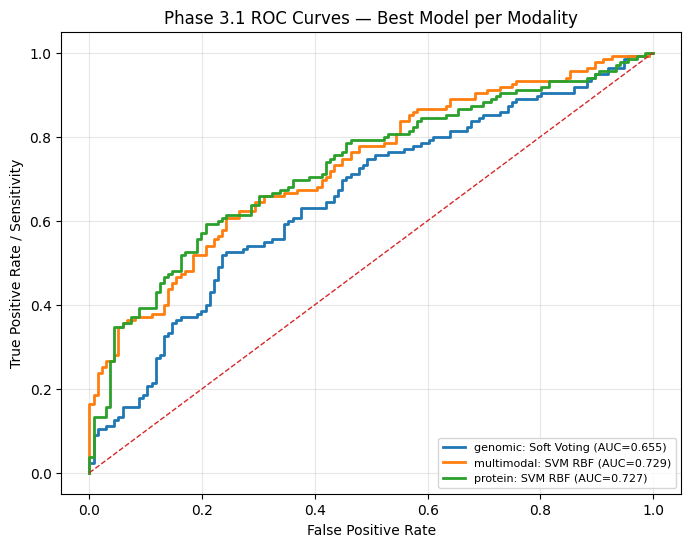

,modality,feature_set,model,roc_auc
1,multimodal,Combined Protein+Genomic,SVM RBF,0.728976
2,protein,Protein-only ProtBERT-SW,SVM RBF,0.727397
0,genomic,Genomic-only K3K4Basic,Soft Voting,0.655392


Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/figures/phase3_1_roc_curves_best_per_modality_light.png


In [22]:
# ============================================================
# ROC CURVES FOR BEST PER MODALITY
# ============================================================

plt.figure(figsize=(8, 6))

roc_rows = []

for _, row in best_validation_per_modality.iterrows():
    fs_name = row["feature_set"]
    model_name = row["model"]
    modality = row["modality"]

    model = best_estimators[fs_name][model_name]
    fs = feature_sets[fs_name]

    score = get_positive_class_score(model, fs["X_test"])

    fpr, tpr, _ = roc_curve(y_test, score)
    auc_value = roc_auc_score(y_test, score)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{modality}: {model_name} (AUC={auc_value:.3f})"
    )

    roc_rows.append({
        "modality": modality,
        "feature_set": fs_name,
        "model": model_name,
        "roc_auc": auc_value
    })

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("Phase 3.1 ROC Curves — Best Model per Modality")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)

roc_path = FIGURE_DIR / "phase3_1_roc_curves_best_per_modality_light.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

roc_summary_df = pd.DataFrame(roc_rows).sort_values(
    by="roc_auc",
    ascending=False
)

display(roc_summary_df)

roc_summary_df.to_csv(
    RESULT_DIR / "phase3_1_roc_summary_best_per_modality_light.csv",
    index=False
)

print("Saved:", roc_path)

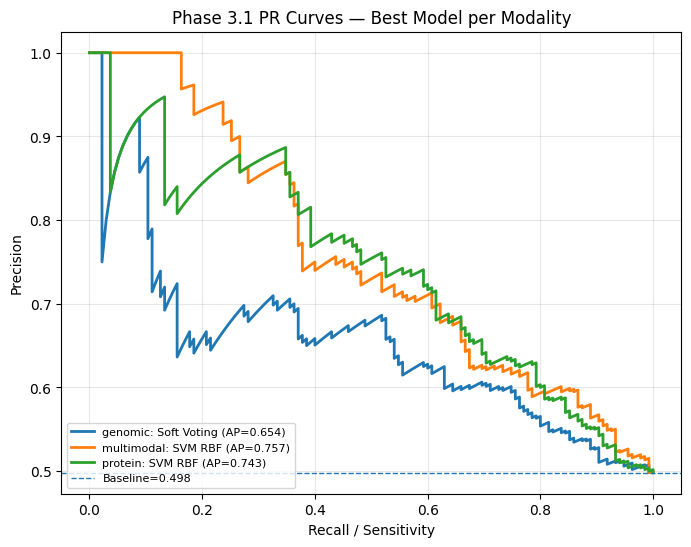

,modality,feature_set,model,pr_auc
1,multimodal,Combined Protein+Genomic,SVM RBF,0.757253
2,protein,Protein-only ProtBERT-SW,SVM RBF,0.743341
0,genomic,Genomic-only K3K4Basic,Soft Voting,0.653991


Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/figures/phase3_1_pr_curves_best_per_modality_light.png


In [23]:
# ============================================================
# PR CURVES FOR BEST PER MODALITY
# ============================================================

plt.figure(figsize=(8, 6))

pr_rows = []

for _, row in best_validation_per_modality.iterrows():
    fs_name = row["feature_set"]
    model_name = row["model"]
    modality = row["modality"]

    model = best_estimators[fs_name][model_name]
    fs = feature_sets[fs_name]

    score = get_positive_class_score(model, fs["X_test"])

    precision, recall, _ = precision_recall_curve(y_test, score)
    ap_value = average_precision_score(y_test, score)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{modality}: {model_name} (AP={ap_value:.3f})"
    )

    pr_rows.append({
        "modality": modality,
        "feature_set": fs_name,
        "model": model_name,
        "pr_auc": ap_value
    })

positive_rate = np.mean(y_test)
plt.axhline(
    y=positive_rate,
    linestyle="--",
    linewidth=1,
    label=f"Baseline={positive_rate:.3f}"
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Phase 3.1 PR Curves — Best Model per Modality")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, alpha=0.3)

pr_path = FIGURE_DIR / "phase3_1_pr_curves_best_per_modality_light.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

pr_summary_df = pd.DataFrame(pr_rows).sort_values(
    by="pr_auc",
    ascending=False
)

display(pr_summary_df)

pr_summary_df.to_csv(
    RESULT_DIR / "phase3_1_pr_summary_best_per_modality_light.csv",
    index=False
)

print("Saved:", pr_path)

In [24]:
# ============================================================
# SAVE ALL MODELS
# ============================================================

for feature_set_name, model_dict in best_estimators.items():
    safe_feature_set = safe_name(feature_set_name)

    for model_name, model in model_dict.items():
        safe_model_name = safe_name(model_name)

        out_path = MODEL_DIR / f"phase3_1_{safe_feature_set}_{safe_model_name}_light.pkl"

        joblib.dump(model, out_path)

        print("Saved:", out_path)

official_model_path = MODEL_DIR / "phase3_1_official_final_selected_model_light.pkl"
joblib.dump(official_model, official_model_path)

print("Official model saved:", official_model_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_logistic_regression_light.pkl
Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl
Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_random_forest_light.pkl
Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_soft_voting_light.pkl
Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_stacking_light.pkl
Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_genomic_only_k3k4basic_l

In [25]:
# ============================================================
# WRITE PHASE 3.1 SUMMARY REPORT
# ============================================================

official_test = official_test_metrics_df.iloc[0]
best_test_table_string = best_test_per_modality_df.to_string(index=False)

summary_text = f"""
# Phase 3.1 — Multimodal Integration Modelling Summary

## Objective

Phase 3.1 compared three feature settings on the same shared multimodal split:

1. Protein-only ProtBERT sliding-window embeddings
2. Genomic-only K3 + K4 + Basic regulatory features
3. Combined Protein + Genomic features

The goal was to test whether multimodal integration improves T2D-associated gene/protein classification beyond either single modality alone.

## Computational Note

A lightweight GridSearchCV was used for this phase to ensure Colab stability.
The same search protocol was applied consistently across feature settings, making the modality comparison fair.
LightGBM was selectively skipped for high-dimensional settings when needed due to runtime constraints.

## Dataset

Shared multimodal genes: {len(train_meta) + len(val_meta) + len(test_meta)}

Train: {len(train_meta)}
Validation: {len(val_meta)}
Test: {len(test_meta)}

Protein features: {X_train_protein.shape[1]}
Genomic features: {X_train_genomic.shape[1]}
Combined features: {X_train_combined.shape[1]}

## Official Model Selection

The official model was selected using validation ROC-AUC.

Selected feature set:
{official_feature_set}

Selected modality:
{official_modality}

Selected model:
{official_model_name}

## Official Test Performance

- Accuracy: {official_test['accuracy']:.4f}
- Precision: {official_test['precision']:.4f}
- Recall/Sensitivity: {official_test['recall_sensitivity']:.4f}
- Specificity: {official_test['specificity']:.4f}
- F1: {official_test['f1']:.4f}
- ROC-AUC: {official_test['roc_auc']:.4f}
- PR-AUC: {official_test['pr_auc']:.4f}
- MCC: {official_test['mcc']:.4f}

Confusion matrix:
- TN: {int(official_test['tn'])}
- FP: {int(official_test['fp'])}
- FN: {int(official_test['fn'])}
- TP: {int(official_test['tp'])}

## Best Model per Modality

{best_test_table_string}

## Interpretation

If the combined Protein + Genomic feature set outperforms both protein-only and genomic-only settings on the held-out test set, this supports multimodal integration.

If the combined model does not outperform the best single modality, this suggests either:
- the modalities are not adding independent signal under raw feature concatenation,
- the combined feature dimensionality is too high for the dataset size,
- stronger regularization or dimensionality reduction may be needed,
- or late fusion / stacking may be more appropriate than raw feature concatenation.

## Next Step

The next step is to interpret the Phase 3.1 results and decide whether to:
1. keep raw feature concatenation,
2. try PCA-reduced integration,
3. try score-level late fusion,
4. or add DNABERT-style genomic embeddings.
"""

summary_path = REPORT_DIR / "phase3_1_multimodal_integration_summary_light.md"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


# Phase 3.1 — Multimodal Integration Modelling Summary

## Objective

Phase 3.1 compared three feature settings on the same shared multimodal split:

1. Protein-only ProtBERT sliding-window embeddings
2. Genomic-only K3 + K4 + Basic regulatory features
3. Combined Protein + Genomic features

The goal was to test whether multimodal integration improves T2D-associated gene/protein classification beyond either single modality alone.

## Computational Note

A lightweight GridSearchCV was used for this phase to ensure Colab stability.
The same search protocol was applied consistently across feature settings, making the modality comparison fair.
LightGBM was selectively skipped for high-dimensional settings when needed due to runtime constraints.

## Dataset

Shared multimodal genes: 1806

Train: 1264
Validation: 271
Test: 271

Protein features: 1024
Genomic features: 356
Combined features: 1380

## Official Model Selection

The official model was selected using validation ROC-AUC.

Selecte

In [26]:
display(grid_results_df)
display(all_validation_df)
display(official_test_metrics_df)
display(diagnostic_test_df)
display(best_test_per_modality_df)
display(threshold_tuning_df)
display(roc_summary_df)
display(pr_summary_df)

,feature_set,modality,n_features,model,best_cv_roc_auc,best_train_roc_auc,overfit_gap_train_minus_cv,best_params
7,Combined Protein+Genomic,multimodal,1380,Logistic Regression,0.728042,0.846929,0.118887,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
8,Combined Protein+Genomic,multimodal,1380,SVM RBF,0.713564,0.969070,0.255506,"{'model__C': 1, 'model__gamma': 'scale'}"
0,Protein-only ProtBERT-SW,protein,1024,Logistic Regression,0.712232,0.805705,0.093473,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
9,Combined Protein+Genomic,multimodal,1380,Random Forest,0.710244,0.987214,0.276971,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
1,Protein-only ProtBERT-SW,protein,1024,SVM RBF,0.707658,0.937969,0.230311,"{'model__C': 1, 'model__gamma': 'scale'}"
2,Protein-only ProtBERT-SW,protein,1024,Random Forest,0.703388,0.985016,0.281628,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
3,Genomic-only K3K4Basic,genomic,356,Logistic Regression,0.646466,0.727563,0.081097,"{'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"
4,Genomic-only K3K4Basic,genomic,356,SVM RBF,0.644601,0.807859,0.163258,"{'model__C': 1, 'model__gamma': 0.001}"
5,Genomic-only K3K4Basic,genomic,356,Random Forest,0.627073,0.985133,0.358060,"{'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}"
6,Genomic-only K3K4Basic,genomic,356,LightGBM,0.623790,0.926514,0.302724,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_samples': 50, 'model__n_estimators': 100, 'model__num_leaves': 7, 'model..."


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
25,Combined Protein+Genomic,multimodal,SVM RBF,validation,0.664207,0.671756,0.647059,0.681481,0.659176,0.729793,0.708498,0.328719,92,43,48,88
29,Combined Protein+Genomic,multimodal,Soft Voting,validation,0.675277,0.681818,0.661765,0.688889,0.671642,0.727397,0.711060,0.350768,93,42,46,90
3,Protein-only ProtBERT-SW,protein,SVM RBF,validation,0.653137,0.650000,0.669118,0.637037,0.659420,0.726743,0.738466,0.306322,86,49,45,91
31,Combined Protein+Genomic,multimodal,Stacking,validation,0.671587,0.676692,0.661765,0.681481,0.669145,0.726416,0.698319,0.343302,92,43,46,90
23,Combined Protein+Genomic,multimodal,Logistic Regression,validation,0.686347,0.686131,0.691176,0.681481,0.688645,0.722985,0.684372,0.372678,92,43,42,94
7,Protein-only ProtBERT-SW,protein,Soft Voting,validation,0.664207,0.661871,0.676471,0.651852,0.669091,0.718573,0.724319,0.328430,88,47,44,92
9,Protein-only ProtBERT-SW,protein,Stacking,validation,0.667897,0.671642,0.661765,0.674074,0.666667,0.713998,0.711991,0.335857,91,44,46,90
1,Protein-only ProtBERT-SW,protein,Logistic Regression,validation,0.664207,0.666667,0.661765,0.666667,0.664207,0.704357,0.690531,0.328431,90,45,46,90
27,Combined Protein+Genomic,multimodal,Random Forest,validation,0.649446,0.647482,0.661765,0.637037,0.654545,0.699564,0.702579,0.298899,86,49,46,90
5,Protein-only ProtBERT-SW,protein,Random Forest,validation,0.616236,0.606667,0.669118,0.562963,0.636364,0.693791,0.715061,0.233419,76,59,45,91


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Combined Protein+Genomic,multimodal,SVM RBF,test,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.32929,96,40,51,84


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
12,Combined Protein+Genomic,multimodal,SVM RBF,test_diagnostic,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.329290,96,40,51,84
11,Combined Protein+Genomic,multimodal,Logistic Regression,test_diagnostic,0.645756,0.658537,0.600000,0.691176,0.627907,0.728813,0.752291,0.292421,94,42,54,81
1,Protein-only ProtBERT-SW,protein,SVM RBF,test_diagnostic,0.664207,0.654930,0.688889,0.639706,0.671480,0.727397,0.743341,0.328971,87,49,42,93
15,Combined Protein+Genomic,multimodal,Stacking,test_diagnostic,0.656827,0.669355,0.614815,0.698529,0.640927,0.727233,0.749346,0.314477,95,41,52,83
3,Protein-only ProtBERT-SW,protein,Soft Voting,test_diagnostic,0.667897,0.664234,0.674074,0.661765,0.669118,0.726797,0.737209,0.335857,90,46,44,91
2,Protein-only ProtBERT-SW,protein,Random Forest,test_diagnostic,0.682657,0.668966,0.718519,0.647059,0.692857,0.725218,0.714782,0.366477,88,48,38,97
14,Combined Protein+Genomic,multimodal,Soft Voting,test_diagnostic,0.642066,0.643939,0.629630,0.654412,0.636704,0.724401,0.746278,0.284134,89,47,50,85
4,Protein-only ProtBERT-SW,protein,Stacking,test_diagnostic,0.667897,0.666667,0.666667,0.669118,0.666667,0.724074,0.734617,0.335784,91,45,45,90
0,Protein-only ProtBERT-SW,protein,Logistic Regression,test_diagnostic,0.667897,0.671756,0.651852,0.683824,0.661654,0.718954,0.727847,0.335858,93,43,47,88
13,Combined Protein+Genomic,multimodal,Random Forest,test_diagnostic,0.653137,0.641379,0.688889,0.617647,0.664286,0.695479,0.698911,0.307290,84,52,42,93


,feature_set,modality,model,dataset,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
1,Combined Protein+Genomic,multimodal,SVM RBF,test,0.664207,0.677419,0.622222,0.705882,0.648649,0.728976,0.757253,0.329290,96,40,51,84
2,Protein-only ProtBERT-SW,protein,SVM RBF,test,0.664207,0.654930,0.688889,0.639706,0.671480,0.727397,0.743341,0.328971,87,49,42,93
0,Genomic-only K3K4Basic,genomic,Soft Voting,test,0.642066,0.682692,0.525926,0.757353,0.594142,0.655392,0.653991,0.291256,103,33,64,71


,official_feature_set,official_modality,official_model,tuned_for,best_threshold,val_f1,val_mcc,val_roc_auc,val_pr_auc,val_recall_sensitivity,val_specificity,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_recall_sensitivity,test_specificity,test_tn,test_fp,test_fn,test_tp
1,Combined Protein+Genomic,multimodal,SVM RBF,f1,0.402,0.725552,0.378685,0.729793,0.708498,0.845588,0.511111,0.680135,0.305516,0.728976,0.757253,0.748148,0.551471,75,61,34,101
0,Combined Protein+Genomic,multimodal,SVM RBF,mcc,0.439,0.724252,0.396156,0.729793,0.708498,0.801471,0.585185,0.659649,0.286173,0.728976,0.757253,0.696296,0.588235,80,56,41,94
2,Combined Protein+Genomic,multimodal,SVM RBF,balanced_accuracy,0.442,0.720539,0.393798,0.729793,0.708498,0.786765,0.600000,0.650177,0.270870,0.728976,0.757253,0.681481,0.588235,80,56,43,92
3,Combined Protein+Genomic,multimodal,SVM RBF,youden_j,0.442,0.720539,0.393798,0.729793,0.708498,0.786765,0.600000,0.650177,0.270870,0.728976,0.757253,0.681481,0.588235,80,56,43,92


,modality,feature_set,model,roc_auc
1,multimodal,Combined Protein+Genomic,SVM RBF,0.728976
2,protein,Protein-only ProtBERT-SW,SVM RBF,0.727397
0,genomic,Genomic-only K3K4Basic,Soft Voting,0.655392


,modality,feature_set,model,pr_auc
1,multimodal,Combined Protein+Genomic,SVM RBF,0.757253
2,protein,Protein-only ProtBERT-SW,SVM RBF,0.743341
0,genomic,Genomic-only K3K4Basic,Soft Voting,0.653991
